In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from scipy.interpolate import UnivariateSpline
from braid_analysis import flymath
import pynumdiff

from align_course_direction_analysis import unifying_algo_analysis as uaa

import figurefirst as fifi

In [2]:
def wrap_angle(a):
    return np.arctan2(np.sin(a), np.cos(a))

### Parameters

In [3]:
fname = '../../../../../../Data/Fig5_Input_Data/animal_trajectories/shark/shark_c.csv'
df_raw = pd.read_csv(fname)

flow_direction = wrap_angle(80*np.pi/180. + np.pi)
flow_condition = 'laminar'
flow_speed = 0.15
body_length = 0.5
locomotion = 'swimming'
medium = 'water'
group = 'aquatic'

interp_dt = 0.01

### Get time stamps and speed -- this is custom per data type

In [4]:
scaling = 0.9 # 1.8 meter diameter observation pools, digitized with -1 to 1 for x and y. 
# swimming speed = 33 cm/sec
speed = 0.33 # m/sec

df_calibrated = df_raw*scaling

# estimate time stamps: find total path length, divide by swimming speed
x_dist = np.sum(np.abs(np.diff(df_calibrated.x)))
y_dist = np.sum(np.abs(np.diff(df_calibrated.y)))
dist = np.sqrt(x_dist**2 + y_dist**2)
print('dist: ', dist)

end_time = dist/speed
timestamps = np.linspace(0, end_time, df_calibrated.shape[0])
df_calibrated['timestamps_sec'] = timestamps

dist:  3.501663769368994


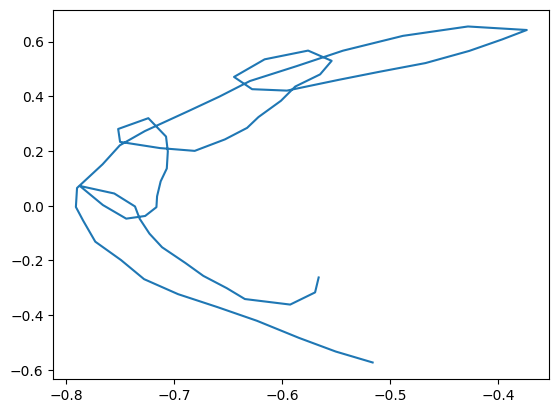

In [5]:
plt.plot(df_calibrated.x.values, df_calibrated.y.values)

### Interpolate

In [6]:
interp_timestamps_sec = np.arange(0, df_calibrated.timestamps_sec.max(), interp_dt)

spline_x = UnivariateSpline(df_calibrated.timestamps_sec, df_calibrated.x, s=1e-4, k=5)  # s=smoothing amount
interp_x = spline_x(interp_timestamps_sec)

spline_y = UnivariateSpline(df_calibrated.timestamps_sec, df_calibrated.y, s=1e-4, k=5)  # s=smoothing amount
interp_y = spline_y(interp_timestamps_sec)

df_calibrated_interp = pd.DataFrame({'timestamps_sec': interp_timestamps_sec,
                                     'x': interp_x,
                                     'y': interp_y})

### Parameters

In [7]:
df_calibrated_interp.shape

(1062, 3)

In [8]:
tix_start = 350
tix_end = 1000

3.5


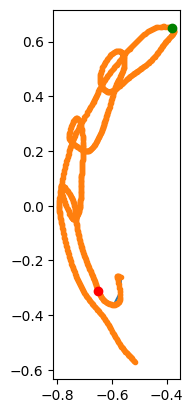

In [9]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(df_calibrated.x.values, df_calibrated.y.values)
ax.plot(df_calibrated_interp.x.values, df_calibrated_interp.y.values, '.')

# when does search start
ax.plot(df_calibrated_interp.x.values[tix_start], df_calibrated_interp.y.values[tix_start], 'o', color='green')

# when does search end?
ax.plot(df_calibrated_interp.x.values[tix_end], df_calibrated_interp.y.values[tix_end], 'o', color='red')

print(df_calibrated_interp.timestamps_sec.values[tix_start])

ax.set_aspect('equal')

In [10]:
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
_, xvel = pynumdiff.savgoldiff(df_calibrated_interp.x, dt, [2, 3, 3])
_, yvel = pynumdiff.savgoldiff(df_calibrated_interp.y, dt, [2, 3, 3])

In [11]:
df_calibrated_interp['xvel'] = xvel
df_calibrated_interp['yvel'] = yvel
df_calibrated_interp['time_relative_to_flash'] = df_calibrated_interp['timestamps_sec'] - df_calibrated_interp.timestamps_sec.values[tix_start]
df_calibrated_interp['obj_id_unique_event'] = fname.split('.')[0]
df_calibrated_interp['obj_id_unique'] = fname.split('.')[0]
df_calibrated_interp = flymath.assign_course_and_ang_vel_to_dataframe(df_calibrated_interp)

df_calibrated_interp.course_smoothish -= flow_direction + np.pi
df_calibrated_interp.course_smoothish = wrap_angle(df_calibrated_interp.course_smoothish)

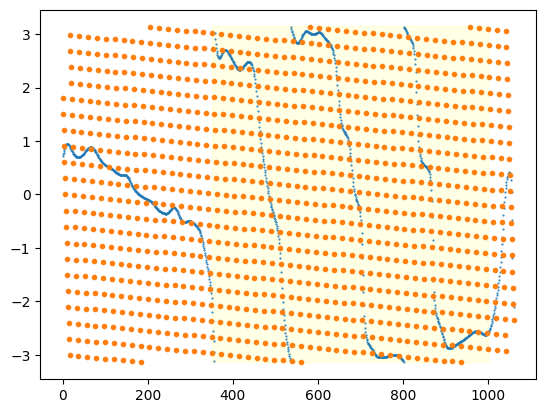

In [12]:
plt.plot(df_calibrated_interp.course_smoothish, '.', markersize=1)

ix = df_calibrated_interp.index.values
slope = -0.3
intercept=1.8
line = slope*ix + intercept

plt.fill_betweenx([-np.pi, np.pi], tix_start, tix_end, color='yellow', alpha=0.1)

plt.plot(ix, wrap_angle(line), '.')

### Parameters to set

In [13]:
min_ix_range = 400
max_ix_range = 600

In [14]:
trajec = df_calibrated_interp

In [15]:
course = trajec.course_smoothish.values
abs_min_ix = tix_start
abs_max_ix = tix_end

In [16]:
trajec['search_phase'] = np.zeros_like(trajec.x.values)
trajec.loc[tix_start:tix_end, 'search_phase']  = 1

trajec['flow_direction'] = [flow_direction]*len(trajec.x.values)
trajec['flow_condition'] = [flow_condition]*len(trajec.x.values)
trajec['flow_speed'] = [flow_speed]*len(trajec.x.values)
trajec['body_length'] = [body_length]*len(trajec.x.values)

trajec['locomotion'] = [locomotion]*len(trajec.x.values)
trajec['medium'] = [medium]*len(trajec.x.values)
trajec['group'] = [group]*len(trajec.x.values)

In [17]:
unifying_algo_fit = uaa.bootstrap_miop_affine_fit(course, 
                                                  abs_min_ix, abs_max_ix, min_ix_range, max_ix_range, 
                                                  npoints = np.min([min_ix_range, 50]), 
                                                  n_bootstraps=10, 
                                                  use_cvx_affine=True, 
                                                  include_translation=True, 
                                                  pis_max = 20, 
                                                  intercept_max = 4,
                                                  huber_M=1.0,
                                                  ignore_large_errors=True,
                                                  error_threshold=2.0,
                                                  large_error_penalty=1.0,
                                                  obj_id=trajec.obj_id_unique_event.values[0],
                                                  timestamps_sec=trajec.timestamps_sec,)

Set parameter Username
Set parameter LicenseID to value 2753061
Academic license - for non-commercial use only - expires 2026-12-11


/home/caveman/PY38/lib/python3.8/site-packages/cvxpy/problems/problem.py:1385: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


In [18]:
unifying_algo_fit['flow_direction'] = flow_direction
unifying_algo_fit['flow_condition'] = flow_condition
unifying_algo_fit['flow_speed'] = flow_speed
unifying_algo_fit['body_length'] = body_length

unifying_algo_fit['locomotion'] = locomotion
unifying_algo_fit['medium'] = medium
unifying_algo_fit['group'] = group



In [19]:
# Sort 
sorted_fit = unifying_algo_fit.sort_values('rmse_affine')
best_ix = sorted_fit.index[0]
best_unifying_algo_fit = unifying_algo_fit.iloc[best_ix]

In [20]:
sorted_fit

,min_ix,max_ix,abs_min_ix,abs_max_ix,min_ix_range,max_ix_range,slope,intercept,rotation,major_axis,...,iteration,obj_id_unique_event,timestep_sec,flow_direction,flow_condition,flow_speed,body_length,locomotion,medium,group
0,437,895,350,1000,400,600,-0.033389,4.197827,-2.909895,0.930567,...,0,shark_c,0.009,-1.745329,laminar,0.15,0.5,swimming,water,aquatic
2,474,971,350,1000,400,600,-0.032673,3.758171,-2.710035,0.749388,...,2,shark_c,0.009,-1.745329,laminar,0.15,0.5,swimming,water,aquatic
3,404,914,350,1000,400,600,-0.032657,3.836668,-2.811321,0.759594,...,3,shark_c,0.009,-1.745329,laminar,0.15,0.5,swimming,water,aquatic
9,549,981,350,1000,400,600,0.001961,1.793942,3.270842,3.601938,...,9,shark_c,0.009,-1.745329,laminar,0.15,0.5,swimming,water,aquatic
8,539,957,350,1000,400,600,0.001783,-4.444195,-3.093872,4.614503,...,8,shark_c,0.009,-1.745329,laminar,0.15,0.5,swimming,water,aquatic
4,574,984,350,1000,400,600,0.001647,2.109539,-2.957972,4.727237,...,4,shark_c,0.009,-1.745329,laminar,0.15,0.5,swimming,water,aquatic
7,386,982,350,1000,400,600,0.002350,-4.764804,1.360967,0.739301,...,7,shark_c,0.009,-1.745329,laminar,0.15,0.5,swimming,water,aquatic
5,456,989,350,1000,400,600,0.001500,-4.148946,-2.895434,5.251261,...,5,shark_c,0.009,-1.745329,laminar,0.15,0.5,swimming,water,aquatic
6,383,860,350,1000,400,600,0.002110,1.616406,2.773482,0.513653,...,6,shark_c,0.009,-1.745329,laminar,0.15,0.5,swimming,water,aquatic
1,428,867,350,1000,400,600,0.001361,2.061694,2.984315,10.716587,...,1,shark_c,0.009,-1.745329,laminar,0.15,0.5,swimming,water,aquatic


In [21]:
ix_all, course, linear_fit_angle, affine_fit_angle, shift_ix_adj = uaa.build_miop_and_affine_predictions_from_model(course, best_unifying_algo_fit)

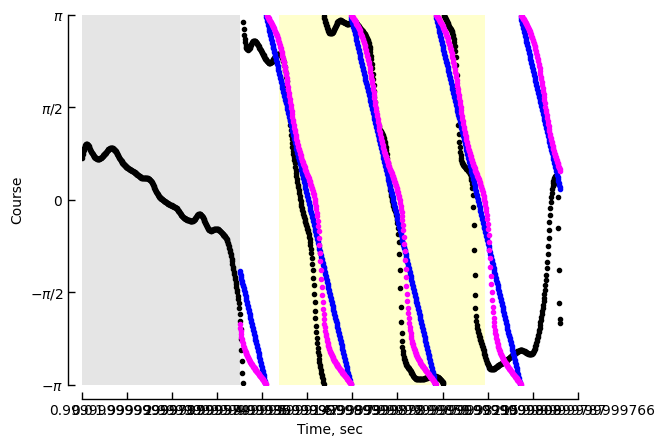

In [22]:
fig = plt.figure()
ax = fig.add_subplot(111)

# shading for before search
ax.fill_betweenx([np.pi, -np.pi], 
                 0, 
                 abs_min_ix, 
                 color='gray', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# add shading for region of interest where fit was applied
min_ix = int(best_unifying_algo_fit.min_ix)
max_ix = int(best_unifying_algo_fit.max_ix)
ax.fill_betweenx([np.pi, -np.pi], 
                 min_ix, 
                 max_ix, 
                 color='yellow', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# plot course, linear fit, and affine fit
ax.plot(ix_all, course, '.', color='black')
ax.plot(ix_all[abs_min_ix:], linear_fit_angle[abs_min_ix:], '.', color='blue')
ax.plot(ix_all[abs_min_ix:], affine_fit_angle[abs_min_ix:], '.', color='magenta')

# Add ticks, labels, etc. 
ax.set_xlim(0, ix_all[-1])
ax.set_ylim(-np.pi, np.pi)

xticks = np.arange( np.min(ix_all), np.max(ix_all) + 50, 100)
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
xticklabels = dt*xticks
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlabel('Time, sec')

ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['$-\pi$', '$-\pi/2$','$0$','$\pi/2$','$\pi$',])
ax.set_ylabel('Course')

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'])

In [23]:
fname_trajec = fname.split('.')[0] + '_trajec.parquet'
trajec.to_parquet(fname_trajec)

unifying_algo_fit.to_parquet(fname.split('.')[0] + '_unifying_analysis.parquet')